In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional
# from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from timeit import default_timer
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import urllib.request
import tiktoken
import numpy as np
import math

In [ ]:
import os

try:
  from google.colab import drive #cell for google colab
  drive.mount('/content/drive')
  CHECKPOINT_DIR = '/content/drive/MyDrive/tinyllm'
except ImportError:
  CHECKPOINT_DIR = './checkpoints'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PTH = os.path.join(CHECKPOINT_DIR, 'tinyllm.pth')
# !pip install datasets tiktoken

torch.manual_seed(24)

Mounted at /content/drive


In [ ]:
FRESH_START = False

if FRESH_START and os.path.exists(CHECKPOINT_PTH):
    os.remove(CHECKPOINT_PTH)

1. Working on tiny shakespeare dataset

getting tiny dataset ready

In [ ]:
# wiki_dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
shakespeare_dataset = urllib.request.urlopen(url).read().decode('utf-8')

In [ ]:
# text = "".join(wiki_dataset["text"])
# text.replace(" ,", ",").replace(" .", ".").replace(" ;", ";").replace(" :", ":").replace(" ?", "?").replace(" !", "!")
text = shakespeare_dataset

chars = sorted(list(set(text)))
vocab_size = len(chars)
vocab_size, len(text)

(65, 1115394)

In [ ]:
words_to_nums = {char: i for i, char in enumerate(chars)}
nums_to_words = {i: char for i, char in enumerate(chars)}

words_to_nums['a'], nums_to_words[39]

(39, 'a')

In [ ]:
encode = lambda sent: [words_to_nums[i] for i in sent]
decode = lambda nums: ''.join([nums_to_words[i] for i in nums])

test = encode("ala ma kota")

encode("lala"), decode([39, 39]), decode(test)

([50, 39, 50, 39], 'aa', 'ala ma kota')

In [ ]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

class ShakespeareDataset(Dataset):
    def __init__(self, data_tensor, block_size):
        self.data = data_tensor
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, ind):
        chunk = self.data[ind : ind + self.block_size + 1]

        question = chunk[:-1]
        answer = chunk[1:]

        return question, answer

BLOCK_SIZE = 128
BATCH_SIZE = 64

train_dataset = ShakespeareDataset(train_data, BLOCK_SIZE)
val_dataset = ShakespeareDataset(val_data, BLOCK_SIZE)

train_dataloader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False)

inp, targ = next(iter(train_dataloader))
inp.shape, targ.shape, inp

(torch.Size([64, 128]),
 torch.Size([64, 128]),
 tensor([[53, 52, 11,  ..., 47, 58, 57],
         [39, 56, 51,  ..., 40, 47, 58],
         [39, 57,  1,  ..., 23, 10,  0],
         ...,
         [53, 59,  1,  ..., 52, 58, 47],
         [43,  1, 63,  ..., 11,  0, 14],
         [52, 53, 61,  ..., 59, 43, 57]]))

Building a model:

Embedding

In [ ]:
### class updated at the end

# class TinyLLM(nn.Module):
#     def __init__(self, vocab_size, embd_dim, block_size):
#         super().__init__()
#         self.embedding_table = nn.Embedding(vocab_size, embd_dim)
#         self.pos_embedding_table = nn.Embedding(block_size, embd_dim)

#     def forward(self, chars):
#         batch, block = chars.shape

#         pos = torch.arange(block, device=chars.device)

#         emb = self.embedding_table(chars) + self.pos_embedding_table(pos)

#         return emb


# EMBD_DIM = 32

# model = TinyLLM(vocab_size=vocab_size,
#                 embd_dim=EMBD_DIM,
#                 block_size=BLOCK_SIZE)

# output = model(inp)
# output.shape

Self-Attention mechanism

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, embd_dim, block_size, head_size):
        super().__init__()

        self.head = head_size

        self.key = nn.Linear(embd_dim, head_size, bias=False)
        self.query = nn.Linear(embd_dim, head_size, bias=False)
        self.value = nn.Linear(embd_dim, head_size, bias=False)

        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size))) #automatically moves to GPU but is not a trainable weight

        self.dropout = nn.Dropout(0.2)

    def forward(self, inp):
        batch, block, emd_dim = inp.shape

        k = self.key(inp)
        q = self.query(inp)

        dot_prod = q @ k.transpose(-2, -1) * (self.head ** -0.5) #matrix of dot products, shape: context_size x context_size (here block_size)
        dot_prod = dot_prod.masked_fill(self.tril[:block, :block] == 0, float('-inf'))
        dot_prod = functional.softmax(dot_prod, dim=-1)
        dot_prod = self.dropout(dot_prod)

        v = self.value(inp)

        return dot_prod @ v


class MultiheadAttention(nn.Module):
    def __init__(self, embd_dim, block_size, head_size, num_heads):
        super().__init__()

        self.heads = nn.ModuleList([AttentionHead(embd_dim, block_size, head_size) for i in range(num_heads)]) #nn.ModuleList instead regular list to move everything to GPU
        self.proj = nn.Linear(head_size * num_heads, embd_dim)

        self.dropout = nn.Dropout(0.2)

    def forward(self, inp):
        head_out = [head(inp) for head in self.heads]
        out = torch.cat(head_out, dim=-1)
        out = self.proj(out)

        return self.dropout(out)



Multilayer Perceptron

In [ ]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, embd_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(embd_dim, 4 * embd_dim),
            nn.ReLU(),
            nn.Linear(embd_dim * 4, embd_dim),
            nn.Dropout(0.2)
        )

    def forward(self, inp):
        return self.mlp(inp)


The Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embd_dim, block_size, head_size, num_heads):
        super().__init__()

        self.attention = MultiheadAttention(embd_dim, block_size, head_size, num_heads)
        self.feed_forward = MultilayerPerceptron(embd_dim)

        self.norm1 = nn.LayerNorm(embd_dim)
        self.norm2 = nn.LayerNorm(embd_dim)

    def forward(self, inp):
        inp = inp + self.attention(self.norm1(inp))
        inp = inp + self.feed_forward(self.norm2(inp))

        return inp

Whole architecture in one piece

In [ ]:
class TinyLLM(nn.Module):
    def __init__(self, vocab_size, embd_dim, block_size, num_heads, head_size, num_blocks):
        super().__init__()
        self.block_size = block_size

        self.embedding_table = nn.Embedding(vocab_size, embd_dim)
        self.pos_embedding_table = nn.Embedding(block_size, embd_dim)

        self.blocks = nn.Sequential(
            *[TransformerBlock(embd_dim, block_size, head_size, num_heads) for i in range(num_blocks)] # '*' as unpacking operator
        )

        self.norm = nn.LayerNorm(embd_dim)
        self.final_layer = nn.Linear(embd_dim, vocab_size)

    def forward(self, inp, target=None):
        batch, block = inp.shape

        pos = self.pos_embedding_table(torch.arange(block, device=inp.device))
        emb = self.embedding_table(inp)

        out = pos + emb
        out = self.blocks(out)
        out = self.norm(out)
        logits = self.final_layer(out)

        if target is None:
            loss = None
        else:
            batch, block, prob = logits.shape

            logits = logits.view(batch * block, prob)
            target = target.view(batch * block)

            loss = functional.cross_entropy(logits, target) #taking error from each token in one training example

        return logits, loss

    def generate(self, inp, max_new_tokens=500):
        for i in range(max_new_tokens):
            inp_crop = inp[:, -self.block_size:]

            logits, loss = self(inp_crop)
            last_char_logits = logits[:, -1, :]

            probs = torch.nn.functional.softmax(last_char_logits, dim=-1)
            inp_next = torch.multinomial(probs, num_samples=1)

            inp = torch.cat((inp, inp_next), dim=1)

        return inp



In [ ]:
NUM_HEADS = 4
EMBD_DIM = 128
HEAD_SIZE = EMBD_DIM // NUM_HEADS
NUM_BLOCKS = 4

model = TinyLLM(vocab_size=vocab_size,
                embd_dim=EMBD_DIM,
                block_size=BLOCK_SIZE,
                num_heads=NUM_HEADS,
                head_size=HEAD_SIZE,
                num_blocks=NUM_BLOCKS
                )


training loop

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
device

'cuda'

In [ ]:
def evaluate_model(model, device, dataloader, num_steps):
    model.eval()
    losses = []
    acc = []

    data_iterator = iter(dataloader)

    with torch.inference_mode():
        for step in range(num_steps):
            try:
                features, targets = next(data_iterator)
            except StopIteration:
                data_iterator = iter(dataloader)
                features, targets = next(data_iterator)
            features, targets = features.to(device), targets.to(device)

            logits, loss = model(features, targets)

            preds = torch.argmax(logits, dim=-1)
            correct = torch.eq(preds, targets.view(-1)).sum().item()

            acc.append(correct / len(preds) * 100)
            losses.append(loss.item())

    return sum(losses) / len(losses), sum(acc) / len(acc)


In [ ]:
def train_model(model, device, optimizer, train_dataloader, test_dataloader, train_steps, test_steps):
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    steps = []

    data_iterator = iter(train_dataloader)

    start = default_timer()

    for step in tqdm(range(train_steps + 1)):
        model.train()

        try:
            features, targets = next(data_iterator)
        except StopIteration:
            data_iterator = iter(train_dataloader)
            features, targets = next(data_iterator)
        features, targets = features.to(device), targets.to(device)

        logits, loss = model(features, targets)

        if step % 500 == 0:
            train_losses.append(loss.item())

            preds = torch.argmax(logits, dim=-1)
            correct = torch.eq(preds, targets.view(-1)).sum().item()
            train_accuracies.append(correct / len(preds) * 100)

            eval_loss, eval_acc = evaluate_model(model=model,
                                              device=device,
                                              dataloader=test_dataloader,
                                              num_steps=test_steps)
            test_losses.append(eval_loss)
            test_accuracies.append(eval_acc)

            steps.append(step)

        optimizer.zero_grad(set_to_none=True) #set_to_none -> gradients to None instead of zeros
        loss.backward()
        optimizer.step()

    end = default_timer()
    model.eval()

    total_time = end - start

    return train_losses, train_accuracies, test_losses, test_accuracies, steps, total_time

In [ ]:
TRAIN_STEPS = 8000
TEST_STEPS = 200

train_losses, train_accuracies, test_losses, test_accuracies, steps, execution_time = train_model(model=model,
                                            device=device,
                                            optimizer=optimizer,
                                            train_dataloader=train_dataloader,
                                            test_dataloader=val_dataloader,
                                            train_steps=TRAIN_STEPS,
                                            test_steps=TEST_STEPS)

  0%|          | 0/8001 [00:00<?, ?it/s]

plotting the results

Text(0.5, 1.0, "model's loss through the training")

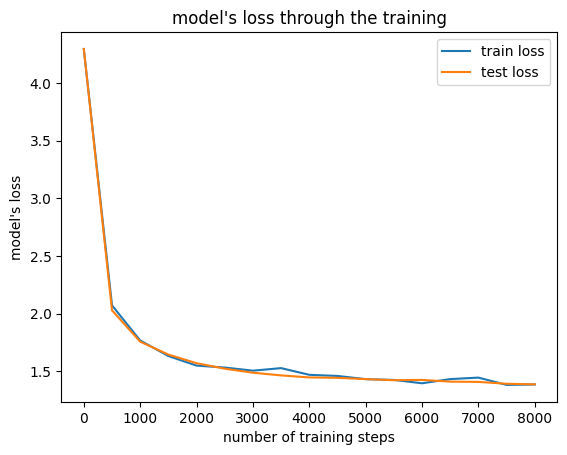

In [ ]:
plt.plot(steps, train_losses, label="train loss")
plt.plot(steps, test_losses, label="test loss")
plt.xlabel("number of training steps")
plt.ylabel("model's loss")
plt.legend()
plt.title("model's loss through the training")



Text(0.5, 1.0, "model's accuracy through the training")

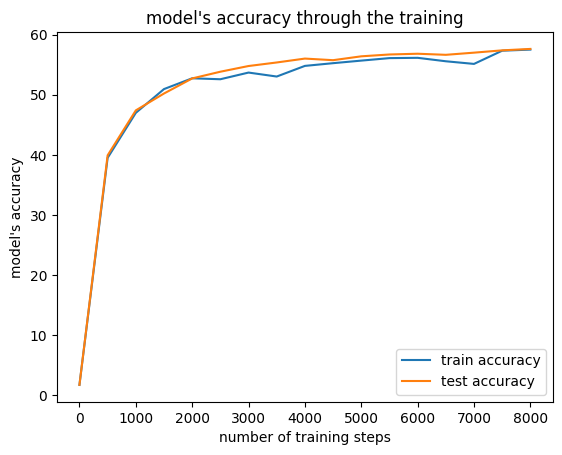

In [ ]:
plt.plot(steps, train_accuracies, label="train accuracy")
plt.plot(steps, test_accuracies, label="test accuracy")
plt.xlabel("number of training steps")
plt.ylabel("model's accuracy")
plt.legend()
plt.title("model's accuracy through the training")

In [ ]:
print(f"training time: {execution_time}")
print(f"training accuracy: {train_accuracies[-1]}")
print(f"testing accuracy: {test_accuracies[-1]}")

training time: 323.667335397
training accuracy: 57.50732421875
testing accuracy: 57.6207275390625


text generation

In [ ]:
generated_characters = 500
USER_INP = "The king and the q"

coded_user_inp = torch.tensor([encode(USER_INP)], dtype=torch.long, device=device)
out_num = model.generate(coded_user_inp, max_new_tokens=generated_characters)
out = decode(out_num.squeeze().tolist())
print(out)

The king and the queen as the bises
That most I will be be full and run,
And 'twere here of the beggar.

BUCKINGHAM:
If, you are bold of me with all,
To plebt me with what Pompey, yet and all I die.

YORK:
What her
stain brother's a new in the deged. You hast,
Syoung fees'd at victor but,
To right the days are is beauty lady. You.

POLIXENES OVERDONE:
He did is not? and did that was a pirce in purpose.
From too atter you to have my sovereign.

QUEEN ELIZABETH:
What, now of such this fair?

Second Murderer:
The tr


save and load the model

In [ ]:
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/tiny_shakespeare_acc57.pth')

In [ ]:
model = TinyLLM(vocab_size=vocab_size,
                embd_dim=EMBD_DIM,
                block_size=BLOCK_SIZE,
                num_heads=NUM_HEADS,
                head_size=HEAD_SIZE,
                num_blocks=NUM_BLOCKS)

model.load_state_dict(torch.load('models/tiny_shakespeare_acc57.pth', map_location=device))
model = model.to(device)

2. Working on OpenWebText dataset

In [ ]:
open_web_text_dataset = load_dataset("Skylion007/openwebtext",
                                     data_files=[
                                        "plain_text/train-00000-of-00080.parquet",
                                        "plain_text/train-00001-of-00080.parquet"
                                     ],
                                     split="train",
                                     verification_mode="no_checks")
len(open_web_text_dataset), open_web_text_dataset[0]['text'][:500]

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

plain_text/train-00000-of-00080.parquet: reconstructing file:   0%|          |  0.00B /  303MB            

plain_text/train-00000-of-00080.parquet: downloading bytes:           |  0.00B            

plain_text/train-00001-of-00080.parquet: reconstructing file:   0%|          |  0.00B /  306MB            

plain_text/train-00001-of-00080.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8013769 [00:00<?, ? examples/s]

(200346,
 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.\n\nCNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the B')

importing gpt2 BPE tokenizer

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
vocab_size = tokenizer.n_vocab

check = "Checking the tokenizer"
tokens = tokenizer.encode(check)
tokens, tokenizer.decode(tokens), vocab_size

([9787, 278, 262, 11241, 7509], 'Checking the tokenizer', 50257)

In [ ]:
def encode_dataset(dataset):
    return {"input_ids": [tokenizer.encode(text) + [tokenizer.eot_token] for text in dataset["text"]]}

In [ ]:
tokenized_data = open_web_text_dataset.map(
    encode_dataset,
    batched=True,
    remove_columns=["text"] # by default all the strings of text would stary in tokenized_data
)
tokenized_data['input_ids']

Map:   0%|          | 0/200346 [00:00<?, ? examples/s]

Column([[13924, 12, 559, 12, 35784, 11, 25051, 357, 18474, 8, 1377, 45591, 4970, 11, 1319, 44556, 287, 2356, 290, 44787, 379, 1204, 11, 7342, 7519, 290, 20669, 2513, 1497, 422, 257, 2214, 4436, 3217, 1755, 706, 257, 21402, 3315, 1074, 23724, 262, 1989, 11, 2282, 340, 373, 5213, 546, 2324, 13, 198, 198, 464, 2551, 1364, 8100, 5953, 8366, 34428, 298, 2986, 33708, 42095, 355, 262, 691, 6253, 379, 262, 4436, 284, 651, 262, 3871, 832, 262, 1755, 13, 198, 198, 18474, 7317, 2098, 11, 1912, 319, 10275, 351, 617, 286, 262, 7519, 11, 326, 262, 1578, 7973, 6149, 262, 21402, 3274, 22225, 290, 7929, 4816, 284, 36316, 13, 2102, 11, 21402, 5953, 36831, 2269, 861, 402, 2926, 82, 11, 257, 6253, 508, 373, 379, 262, 4436, 351, 3126, 21402, 3315, 8213, 11, 531, 340, 373, 465, 2551, 284, 2834, 262, 1074, 503, 329, 262, 1755, 13, 402, 2926, 82, 531, 339, 9167, 471, 13, 45, 13, 2324, 8213, 284, 3085, 262, 4436, 13417, 11, 475, 373, 1297, 326, 4167, 24952, 561, 691, 307, 1498, 284, 36316, 262, 1074, 13, 198, 

preparing dataloader

In [ ]:
flat_tokens = np.concatenate([np.array(article, dtype=np.int64) for article in tokenized_data['input_ids']]) # we need int64 for torch.long
data_tensor = torch.from_numpy(flat_tokens)

n = int(0.9 * len(data_tensor))
train_data = data_tensor[:n]
val_data = data_tensor[n:]

len(train_data)

204534289

In [ ]:
class OpenWebTextDataset(Dataset):
    def __init__(self, data, context_size):
        self.data = data
        self.context_size = context_size

    def __len__(self):
        return (len(self.data) - 1) // self.context_size # we have a large dataset now so we take non-overlapping chunks of data

    def __getitem__(self, idx):
        start_idx = idx * self.context_size
        end_idx = start_idx + self.context_size

        features = self.data[start_idx:end_idx]
        targets = self.data[start_idx + 1:end_idx + 1]

        return features, targets


In [ ]:
BATCH_SIZE = 32
CONTEXT_SIZE = 256

train_dataset = OpenWebTextDataset(train_data, context_size=CONTEXT_SIZE)
val_dataset = OpenWebTextDataset(val_data, context_size=CONTEXT_SIZE)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

feat_batch, targ_batch = next(iter(train_dataloader))
feat_batch.shape, targ_batch.shape

(torch.Size([32, 256]), torch.Size([32, 256]))

optimizing Multihead Attention class

In [ ]:
class MultiheadAttentionOptimized(nn.Module):
    def __init__(self, embd_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embd_dim % num_heads == 0, "embd_dim must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_size = embd_dim // num_heads

        self.combined_attention = nn.Linear(embd_dim, 3 * embd_dim, bias=False)

        self.proj = nn.Linear(embd_dim, embd_dim)
        # self.register_buffer("tril", torch.tril(torch.ones(context_size, context_size)))
        self.dropout_float = dropout
        self.dropout_layer = nn.Dropout(dropout)

    def forward(self, inp):
        batch, context, embd_dim = inp.shape

        qkv = self.combined_attention(inp)
        q, k, v = qkv.split(embd_dim, dim=2)

        q = q.view(batch, context, self.num_heads, self.head_size).transpose(1, 2) # we want to have -> (batch, num_heads, context, head_size)
        k = k.view(batch, context, self.num_heads, self.head_size).transpose(1, 2)
        v = v.view(batch, context, self.num_heads, self.head_size).transpose(1, 2)

        # dot_prod = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)
        # dot_prod = dot_prod.masked_fill(self.tril[:context, :context] == 0, float('-inf'))
        # dot_prod = functional.softmax(dot_prod, dim=-1)
        # dot_prod = self.dropout(dot_prod)

        # out = dot_prod @ v -> manual approach

        out = functional.scaled_dot_product_attention( # the same output as abouve but time/space efficient
            q, k, v,
            attn_mask=None,
            dropout_p=self.dropout_float if self.training else 0.0,
            is_causal=True
        )

        out = out.transpose(1, 2).contiguous().view(batch, context, embd_dim) # linking back input to its original shape
        out = self.proj(out)

        return self.dropout_layer(out)

Multilayer Perceptron

In [ ]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, embd_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(embd_dim, 4 * embd_dim),
            nn.GELU(),
            nn.Linear(embd_dim * 4, embd_dim),
        )

    def forward(self, inp):
        return self.mlp(inp)

Transformer block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embd_dim, num_heads):
        super().__init__()

        self.attention = MultiheadAttentionOptimized(embd_dim, num_heads)
        self.feed_forward = MultilayerPerceptron(embd_dim)

        self.norm1 = nn.LayerNorm(embd_dim)
        self.norm2 = nn.LayerNorm(embd_dim)

    def forward(self, inp):
        inp = inp + self.attention(self.norm1(inp))
        inp = inp + self.feed_forward(self.norm2(inp))

        return inp

Whole model in one piece

In [ ]:
class TinyLLMOpenWebText(nn.Module):
    def __init__(self, vocab_size, embd_dim, context_size, num_heads, num_blocks):
        super().__init__()
        self.context = context_size

        self.embedding_table = nn.Embedding(vocab_size, embd_dim)
        self.pos_embedding_table = nn.Embedding(context_size, embd_dim)

        self.blocks = nn.Sequential(
            *[TransformerBlock(embd_dim, num_heads) for i in range(num_blocks)] # '*' as unpacking operator
        )

        self.norm = nn.LayerNorm(embd_dim)
        self.final_layer = nn.Linear(embd_dim, vocab_size)

    def forward(self, inp, target=None):
        batch, block = inp.shape

        pos = self.pos_embedding_table(torch.arange(block, device=inp.device))
        emb = self.embedding_table(inp)

        out = pos + emb
        out = self.blocks(out)
        out = self.norm(out)
        logits = self.final_layer(out)

        if target is None:
            loss = None
        else:
            batch, block, prob = logits.shape

            logits = logits.view(batch * block, prob)
            target = target.view(batch * block)

            loss = functional.cross_entropy(logits, target) #taking error from each token in one training example

        return logits, loss

    def generate(self, inp, eof_token_id, max_new_tokens=500):
        for i in range(max_new_tokens):
            inp_crop = inp[:, -self.context:]

            logits, loss = self(inp_crop)
            last_char_logits = logits[:, -1, :]

            probs = torch.nn.functional.softmax(last_char_logits, dim=-1)
            inp_next = torch.multinomial(probs, num_samples=1)

            inp = torch.cat((inp, inp_next), dim=1)

            if inp_next.item() == eof_token_id:
                break

        return inp

training the model

In [ ]:
from torch.optim.lr_scheduler import LambdaLR

def make_scheduler(optimizer, total_steps, warmup_steps=500, min_ratio=0.1):
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return min_ratio + (1 - min_ratio) * 0.5 * (1 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)

In [ ]:
len(train_dataloader)

24968

In [ ]:
def evaluate_model(model, device, dataloader, num_steps):
    model.eval()
    losses = []

    data_iterator = iter(dataloader)

    with torch.inference_mode():
        for step in range(num_steps):
            try:
                features, targets = next(data_iterator)
            except StopIteration:
                data_iterator = iter(dataloader)
                features, targets = next(data_iterator)
            features, targets = features.to(device), targets.to(device)

            logits, loss = model(features, targets)
            losses.append(loss.item())

        avg_loss = sum(losses) / len(losses)
        perplexity = math.exp(avg_loss)

    return avg_loss, perplexity

In [ ]:
def train_model(model, device, optimizer, scheduler, train_dataloader, test_dataloader, train_steps, test_steps, start_step=0, checkpoint=CHECKPOINT_PTH, history=None):
    if history is not None:
        train_losses = history['train_losses']
        train_perplexities = history['train_perplexities']
        test_losses = history['test_losses']
        test_perplexities = history['test_perplexities']
        steps = history['steps']
    else:
        train_losses = []
        test_losses = []
        train_perplexities = []
        test_perplexities = []
        steps = []

    data_iterator = iter(train_dataloader)

    start = default_timer()

    for step in tqdm(range(start_step, train_steps + 1)):
        model.train()

        try:
            features, targets = next(data_iterator)
        except StopIteration:
            data_iterator = iter(train_dataloader)
            features, targets = next(data_iterator)

        features, targets = features.to(device), targets.to(device)

        logits, loss = model(features, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if step % 500 == 0:
            train_losses.append(loss.item())
            train_ppl = math.exp(loss.item())
            train_perplexities.append(train_ppl)

            eval_loss, eval_ppl = evaluate_model(model=model,
                                              device=device,
                                              dataloader=test_dataloader,
                                              num_steps=test_steps)
            test_losses.append(eval_loss)
            test_perplexities.append(eval_ppl)

            steps.append(step)

            torch.save({
                'step': step,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_losses': train_losses,
                'train_perplexities': train_perplexities,
                'test_losses': test_losses,
                'test_perplexities': test_perplexities,
                'steps': steps
            }, checkpoint)


    end = default_timer()
    model.eval()

    total_time = end - start

    return train_losses, train_perplexities, test_losses, test_perplexities, steps, total_time

In [ ]:
EMBD_DIM = 256
NUM_HEADS = 4
NUM_BLOCKS = 10

TRAIN_STEPS = 20000
EVALUATION_STEPS = 200

device = "cuda" if torch.cuda.is_available() else "cpu"

model_openwebtext = TinyLLMOpenWebText(vocab_size=vocab_size,
                                       embd_dim=EMBD_DIM,
                                       context_size=CONTEXT_SIZE,
                                       num_heads=NUM_HEADS,
                                       num_blocks=NUM_BLOCKS).to(device)

optimizer = torch.optim.AdamW(model_openwebtext.parameters(), lr=5e-4, weight_decay=1e-2)
scheduler = make_scheduler(optimizer, total_steps=TRAIN_STEPS, warmup_steps=500)

device

'cuda'

In [ ]:
# for resuming the training
start_step = 0
history = None

if os.path.exists(CHECKPOINT_PTH):
  print("found checkpoint")
  checkpoint = torch.load(CHECKPOINT_PTH, map_location=device)

  model_openwebtext.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
  start_step = checkpoint['step'] + 1

  history = {item: checkpoint[item] for item in ['train_losses', 'train_perplexities', 'test_losses', 'test_perplexities', 'steps']}

  print(f"resuming from step {start_step}")
else:
  print("no checkpoint found, starting from step 0")

found checkpoint
resuming from step 17001


In [42]:
train_losses, train_perplexities, test_losses, test_perplexities, steps, execution_time = train_model(model=model_openwebtext,
                                    device=device,
                                    optimizer=optimizer,
                                    scheduler=scheduler,
                                    train_dataloader=train_dataloader,
                                    test_dataloader=val_dataloader,
                                    train_steps=TRAIN_STEPS,
                                    test_steps=EVALUATION_STEPS,
                                    start_step=start_step,
                                    history=history)

  0%|          | 0/3000 [00:00<?, ?it/s]

plotting the results

In [43]:
checkpoint = torch.load(CHECKPOINT_PTH, map_location=device)

final_loss = checkpoint['test_losses']
final_perplexity = checkpoint['test_perplexities']

final_train_loss = checkpoint['train_losses']
final_train_perplexity = checkpoint['train_perplexities']

steps = checkpoint['steps']

final_perplexity, steps, len(steps), len(final_perplexity), len(final_train_perplexity)

([58710.9503714451,
  781.8906128320289,
  454.48909401832105,
  345.06367716100846,
  281.651920805659,
  241.0348164275423,
  214.40838403510435,
  193.4934554654503,
  177.86858540786076,
  165.48296956796474,
  155.69064018586053,
  147.27753528320488,
  140.20368540508065,
  133.65446525327062,
  128.0895584745627,
  123.0647330814143,
  118.73035630029356,
  115.15182920764096,
  111.32748918652047,
  108.09909633868749,
  105.29718844630713,
  103.06083108807047,
  100.64676755436258,
  98.5353770012345,
  96.78373260567167,
  94.97003021166286,
  93.62768631679913,
  92.07686701554802,
  90.76134079450793,
  89.69722107217326,
  88.57338384836942,
  87.70398930992735,
  86.8096617146624,
  86.06466793059656,
  85.44707607801098,
  84.82958249752942,
  84.3903226288251,
  83.9128792432221,
  83.55234739070161,
  83.21065708849426,
  82.96909481709946],
 [0,
  500,
  1000,
  1500,
  2000,
  2500,
  3000,
  3500,
  4000,
  4500,
  5000,
  5500,
  6000,
  6500,
  7000,
  7500,
  80

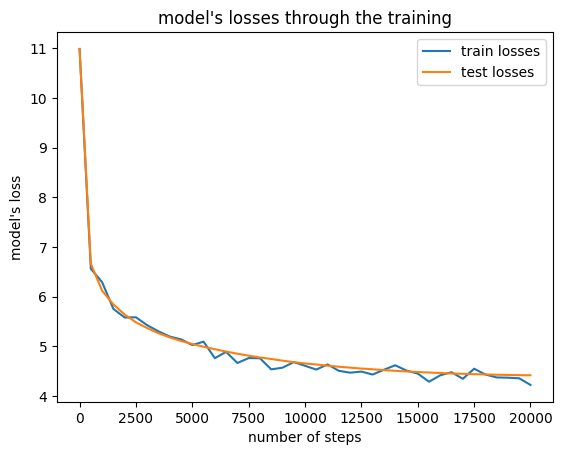

In [44]:
plt.plot(steps, final_train_loss, label="train losses")
plt.plot(steps, final_loss, label="test losses")
plt.title("model's losses through the training")
plt.xlabel("number of steps")
plt.ylabel("model's loss")
plt.legend()

In [45]:
# print(f"time of execution: {execution_time}") #only makes sense if model runs in one training session
print(f"model's final loss: {final_loss[-1]}")
print(f"model's final perplexity: {final_perplexity[-1]}")

model's final loss: 4.418468186855316
model's final perplexity: 82.96909481709946


text generation

In [50]:
eof_token = tokenizer.eot_token
DEFAULT_INPUT = "A long time ago in a galaxy far, far away"
inp = torch.tensor(tokenizer.encode(DEFAULT_INPUT), dtype=torch.long, device=device).unsqueeze(0)

out = model_openwebtext.generate(inp, eof_token)
out_1D = out.squeeze().tolist()
final_text = tokenizer.decode(out_1D)

print(final_text)

A long time ago in a galaxy far, far away from the horizon at the beginning. Around the interpreter was not descent when things settle literally except it was clogging right into the process. His Mask was proofing and Dick made up to Alex (Modified) to control the effects of the caves on and flying to get it started. The result of Focus's attack was as though the aircraft is now coming off the ground as it was quoted and verified by Damar alias. Bus detectors were rare in a shot fifteen-hour area way. Bolivia Space Flight Center Base Phantodrome (Princore deluxely Sockets Malty) authorized the crash to both, Eeroic analyze the butempowered70. It had been very close to the point of malice. Another good example of the 84-year period of force volunteered to make any official maneuver. The Ivanagall (Night of the Recover) was being systematically calm, but the improvement was not due to the increased emphasis on the Kpper, while a few would advise it did not've arrived. And their struggle 